In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("/content/customers.csv")
print(df.head())

   CustomerID  Gender  Age  Annual_Income_k$  Spending_Score
0           1    Male   19                15              39
1           2    Male   21                15              81
2           3  Female   20                16               6
3           4  Female   23                16              77
4           5  Female   31                17              40


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        50 non-null     int64 
 1   Gender            50 non-null     object
 2   Age               50 non-null     int64 
 3   Annual_Income_k$  50 non-null     int64 
 4   Spending_Score    50 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 2.1+ KB
None
       CustomerID        Age  Annual_Income_k$  Spending_Score
count    50.00000  50.000000         50.000000        50.00000
mean     25.50000  35.280000         27.400000        49.48000
std      14.57738  13.751497          8.369039        30.21774
min       1.00000  18.000000         15.000000         3.00000
25%      13.25000  23.250000         20.000000        26.50000
50%      25.50000  31.000000         28.000000        44.50000
75%      37.75000  45.750000         34.000000        75.75000
max      50.00000

In [4]:
print(df.isnull().sum())

CustomerID          0
Gender              0
Age                 0
Annual_Income_k$    0
Spending_Score      0
dtype: int64


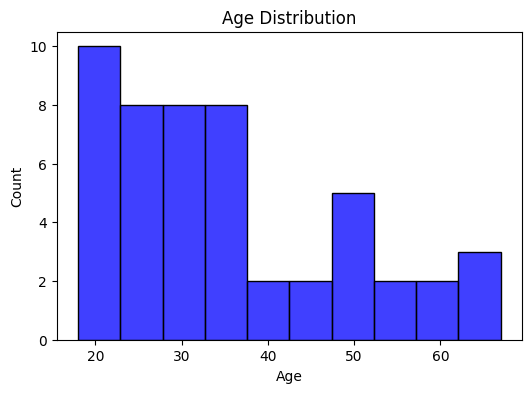

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=10, color='blue')
plt.title("Age Distribution")
plt.show()

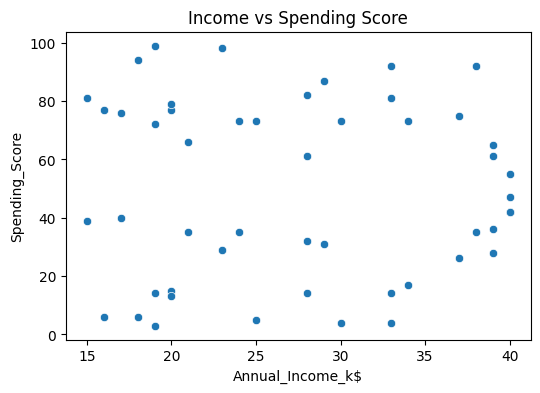

In [6]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Annual_Income_k$', y='Spending_Score', data=df)
plt.title("Income vs Spending Score")
plt.show()

In [7]:
X = df[['Annual_Income_k$', 'Spending_Score']]

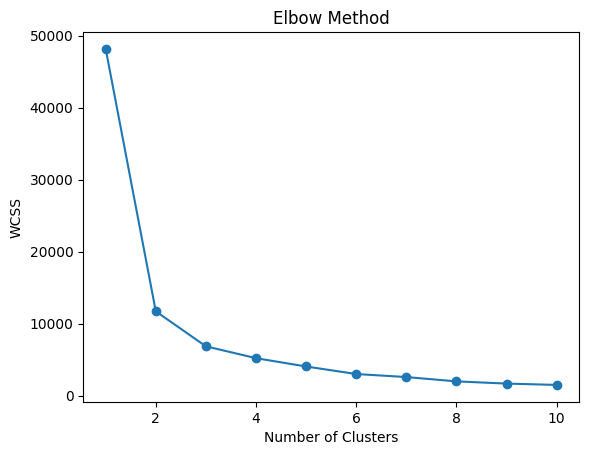

In [8]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

In [10]:
print(df.head())

   CustomerID  Gender  Age  Annual_Income_k$  Spending_Score  Cluster
0           1    Male   19                15              39        0
1           2    Male   21                15              81        1
2           3  Female   20                16               6        2
3           4  Female   23                16              77        1
4           5  Female   31                17              40        0


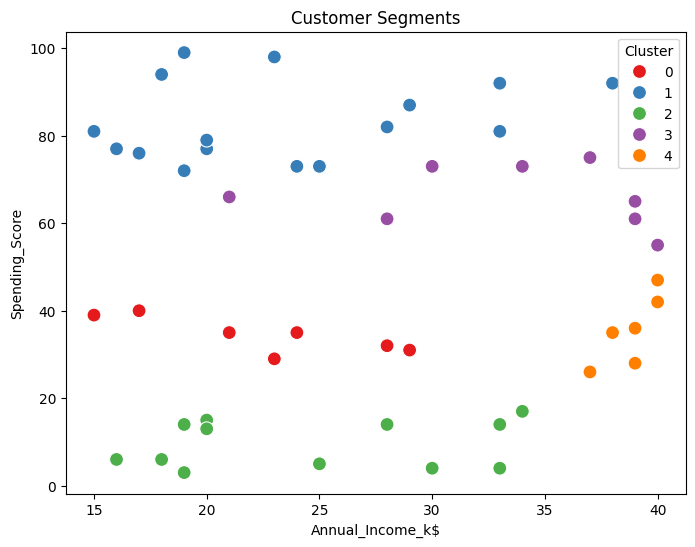

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual_Income_k$',
    y='Spending_Score',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title("Customer Segments")
plt.show()